# Cleaning — ECB Rate Shock & SME Failures

## Objective
Build the analysis inputs: assign sectors to treatment/control by bank-credit dependence, assemble the monthly panel, and define a clean sample that excludes the COVID/PGE window. Export the processed files used by notebook 03.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

sys.path.insert(0, str(Path().resolve().parent))
from src.data_loader import load_failures, load_sector_debt_structure, SECTOR_LABELS
from src import cleaning

Path('../outputs').mkdir(exist_ok=True)
Path('../data/processed').mkdir(exist_ok=True)
print('Environment ready')

Environment ready


## 1. Treatment group: bank-credit dependence
Each sector is scored by the FIBEN bank-debt share (ratio BE), averaged over 2018-2021, then split at the median into treatment (high dependence) and control.

,label,bank_dependence,treated
AZ,Agriculture,80.6,True
I,Accommodation & food,71.7,True
PS,"Education, health, personal services",68.8,True
MN,Business services,61.3,True
G,Trade & auto repair,60.0,True
FZ,Construction,59.4,False
BE,Industry,38.4,False
JZ,Information & communication,31.7,False
H,Transport & storage,27.7,False


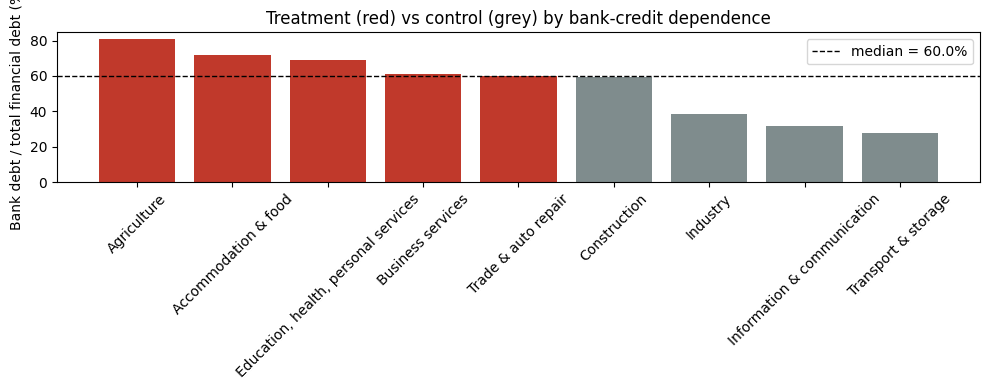

In [2]:
debt = load_sector_debt_structure()
dependence = cleaning.bank_credit_dependence(debt)
treatment = cleaning.assign_treatment(dependence)
treatment['label'] = [SECTOR_LABELS[s] for s in treatment.index]
display(treatment[['label', 'bank_dependence', 'treated']].round(1))

colors = treatment['treated'].map({True: '#c0392b', False: '#7f8c8d'})
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(treatment['label'], treatment['bank_dependence'], color=colors)
ax.axhline(treatment['bank_dependence'].median(), color='black', ls='--', lw=1,
           label=f"median = {treatment['bank_dependence'].median():.1f}%")
ax.set_ylabel('Bank debt / total financial debt (%)')
ax.set_title('Treatment (red) vs control (grey) by bank-credit dependence')
ax.tick_params(axis='x', rotation=45)
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/treatment_split.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations on the treatment split:** the high-dependence (treated) sectors are agriculture, accommodation & food, personal services, business services and trade; the low-dependence (control) sectors are construction, industry, information-communication and transport. Construction sits just below the median, so the split is sensitive there — notebook 03 tests alternative thresholds.

## 2. Panel and COVID/PGE exclusion
The dependent variable is the 12-month rolling cumulative count of PME failures. The clean sample keeps the 2015-2019 baseline and the post-July-2022 period, dropping 2020-01 to 2022-06 (the PGE-suppressed years and the rebound ramp).

panel rows: 2736 | sectors: 9
in-sample rows: 945 | excluded (covid): 270


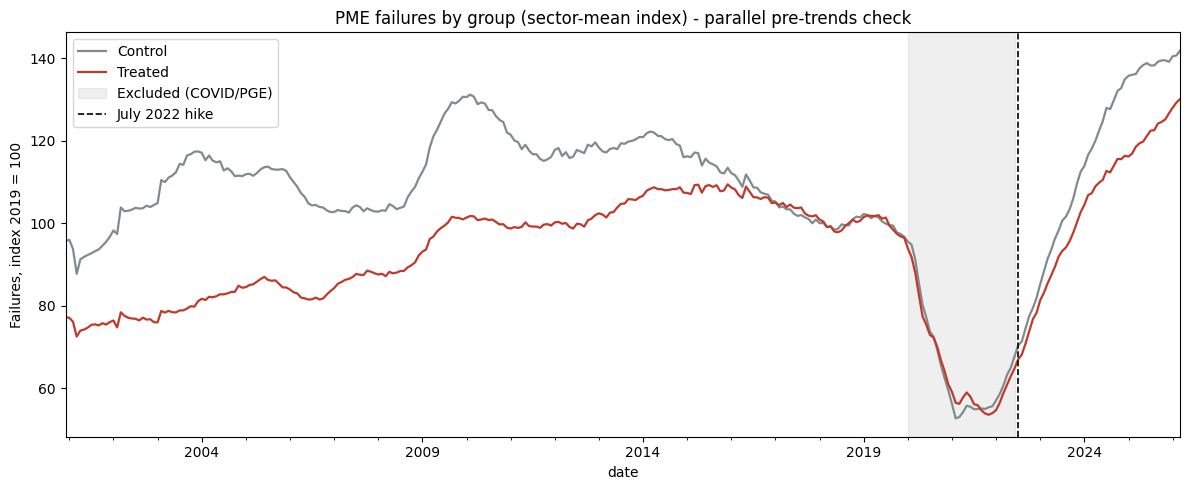

In [3]:
failures = load_failures()
panel = cleaning.build_panel(failures, treatment)
print('panel rows:', len(panel), '| sectors:', panel['sector'].nunique())
print('in-sample rows:', int(panel['in_sample'].sum()),
      '| excluded (covid):', int(panel['in_covid'].sum()))

base = (panel[panel['date'].dt.year == 2019]
        .groupby('sector')['failures'].mean())
panel['idx'] = panel['failures'] / panel['sector'].map(base) * 100
grp = (panel.groupby([panel['date'], 'treated'])['idx'].mean()
       .unstack().rename(columns={1: 'Treated', 0: 'Control'}))

fig, ax = plt.subplots(figsize=(12, 5))
grp.plot(ax=ax, color={'Treated': '#c0392b', 'Control': '#7f8c8d'}, linewidth=1.6)
ax.axvspan(cleaning.COVID_START, cleaning.COVID_END, alpha=0.12, color='gray',
           label='Excluded (COVID/PGE)')
ax.axvline(cleaning.ECB_FIRST_HIKE, color='black', ls='--', lw=1.2, label='July 2022 hike')
ax.set_ylabel('Failures, index 2019 = 100')
ax.set_title('PME failures by group (sector-mean index) - parallel pre-trends check')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/panel_windows.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations on the panel:** before 2020 the treated and control groups track each other reasonably well (supporting the parallel-trends assumption), both collapse during the PGE years (excluded), then the post-2022 period is where any divergence attributable to the rate shock would appear.

## 3. Export processed files

In [4]:
treatment.to_csv('../data/processed/treatment.csv')
panel.to_csv('../data/processed/sector_panel.csv', index=False)
print('treatment.csv and sector_panel.csv written')

treatment.csv and sector_panel.csv written
